# E1 — the RK-PINN loss, with no network

**Purpose.** A literal port of §3.2 to an ODE is *degenerate*: the paper's network input is
a spatial index into the state, and van der Pol's state has only two components, so the
$2(q+1)$ stage values are simply free parameters and Newton solves them outright.

That degeneracy is what makes this a good test. We hand `torch.optim.LBFGS` — the paper's
optimiser — the exact loss the network will see, on a problem whose answer `rk_core.irk_step`
already knows to machine precision.

> A wrong sign or tableau index would **still** drive the SSE to zero, at a solution of the
> *wrong* equations. So the test is agreement with Newton, never the size of the loss.

Three properties of the loss come out of this, and each one constrains E3.

Produced by `e1_recovery.py`, `e1_branches.py`, `e1_folds.py` → `results/`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent / "_shared"))
RESULTS, FIGURES = HERE / "results", HERE / "figures"
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "font.size": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
C_EXACT, C_PRIN, C_SPUR = "#33322e", "#2a78d6", "#e34948"

from loss import D_HI, D_LO, MU, Y0
from rk_core import gauss_legendre_tableau, irk_step, reference, vdp

## 1. Recovery — and why descent gets only half the digits

The loss is a **squared** residual, $\mathrm{SSE} = \sum \|r\|^2$. Near the solution it is
quadratically flat, so the *parameter* error scales as $\sqrt{\mathrm{SSE}}$, not $\mathrm{SSE}$.
Newton drives $|r|$ itself to $10^{-16}$; descent on the square cannot.

This is a floor on **any** gradient-trained RK-PINN, independent of network capacity — and it
is a *different* floor from the capacity one E3 anticipates.

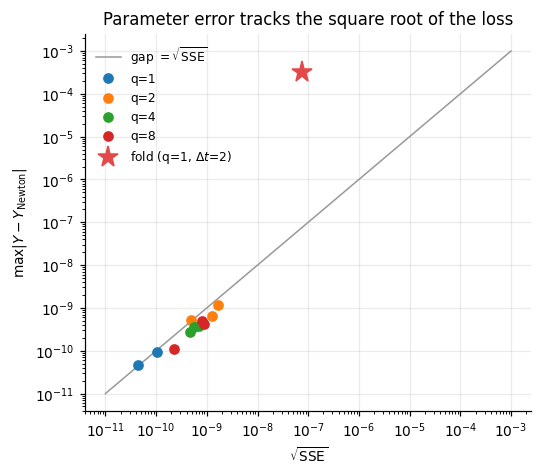

non-fold cells: gap / sqrt(SSE) in [0.48, 1.07]


,q,dt,sse,sqrt_sse,gap,ratio,smallest_sv,endpoint_gap,at_fold
0,1,0.5,1.125805e-20,1.061040e-10,9.523671e-11,0.897579,9.775510e-01,7.221478e-11,False
1,1,1.0,1.983557e-21,4.453714e-11,4.746004e-11,1.065628,8.853412e-01,1.748535e-11,False
2,1,2.0,5.544903e-15,7.446410e-08,3.245079e-04,4357.909925,2.857768e-09,9.176230e-04,True
3,2,0.5,1.640573e-18,1.280849e-09,6.312781e-10,0.492859,9.537864e-01,9.984694e-10,False
4,2,1.0,2.673239e-18,1.635004e-09,1.183512e-09,0.723858,8.369449e-01,6.450420e-10,False
5,2,2.0,2.323474e-19,4.820243e-10,5.090401e-10,1.056047,1.543222e-01,6.901868e-10,False
6,4,0.5,2.205824e-19,4.696620e-10,2.714089e-10,0.577881,9.484194e-01,1.859573e-10,False
7,4,1.0,5.015952e-19,7.082339e-10,3.686322e-10,0.520495,8.343603e-01,3.531917e-10,False
8,4,2.0,3.098355e-19,5.566287e-10,3.623601e-10,0.650991,4.030346e-01,2.612141e-10,False
9,8,0.5,4.925748e-20,2.219403e-10,1.107450e-10,0.498985,9.500190e-01,9.458332e-11,False


In [2]:
rec = pd.read_csv(RESULTS / "e1_recovery.csv")
ok, fold = rec[~rec.at_fold], rec[rec.at_fold]

fig, ax = plt.subplots(figsize=(5.0, 4.4))
lo, hi = 1e-11, 1e-3
ax.plot([lo, hi], [lo, hi], "-", color="0.6", lw=1, label=r"gap $=\sqrt{\rm SSE}$")
for q, g in ok.groupby("q"):
    ax.loglog(g.sqrt_sse, g.gap, "o", label=f"q={q}")
ax.loglog(fold.sqrt_sse, fold.gap, "*", ms=14, color=C_SPUR,
          label="fold (q=1, $\\Delta t$=2)")
ax.set_xlabel(r"$\sqrt{\rm SSE}$"); ax.set_ylabel(r"$\max|Y - Y_{\rm Newton}|$")
ax.set_title("Parameter error tracks the square root of the loss")
ax.legend(fontsize=8); fig.tight_layout()
fig.savefig(FIGURES / "e1_half_the_digits.png"); plt.show()

print(f"non-fold cells: gap / sqrt(SSE) in [{ok.ratio.min():.2f}, {ok.ratio.max():.2f}]")
rec

The one starred point is not a failure of the code. It sits on a **fold**, where the
loss flattens from quadratic to quartic, so the error goes as $\mathrm{SSE}^{1/4}$ instead.
That is the next section.

## 2. An exact fold

At $q=1$ (implicit midpoint), $\Delta t = 2$, $y^n = (2,0)$, the stage equation
$Y = y^n + \tfrac{\Delta t}{2} f(Y)$ gives $Y_1 = 2 + Y_2$, and substituting reduces it
**exactly** to

$$Y_1\,(Y_1 - 1)^2 = 0$$

a double root at $Y_1 = 1$ and a simple root at $Y_1 = 0$. At the double root two solutions
of the stage system have merged, the stage Jacobian
$J = \begin{pmatrix} 1 & -1 \\ -1 & 1\end{pmatrix}$ is exactly singular, and the residual
acquires a null direction.

Along that line the stage residual is available in closed form. With $Y=(Y_1, Y_1-2)$ the
first component of $r$ vanishes identically and the second is exactly $r_2 = Y_1(Y_1-1)^2$, so

$$\mathrm{SSE}(Y_1) = \big[Y_1 (Y_1-1)^2\big]^2
  \;\sim\; \begin{cases} Y_1^2 & \text{near the simple root} \\[2pt]
                          (Y_1-1)^4 & \text{near the double root} \end{cases}$$

Quadratic at a simple root, **quartic** at the fold. Reaching $\mathrm{SSE} = \varepsilon$ leaves you
$\varepsilon^{1/2}$ from a simple root but only $\varepsilon^{1/4}$ from a fold — half the digits
becomes a quarter.

,root,Y1,Y2,residual,smallest_sv,multiplicity,is_fold
0,Y1=0,0.0,-2.0,0.0,0.618034,1,False
1,Y1=1,1.0,-1.0,0.0,0.000000,2,True


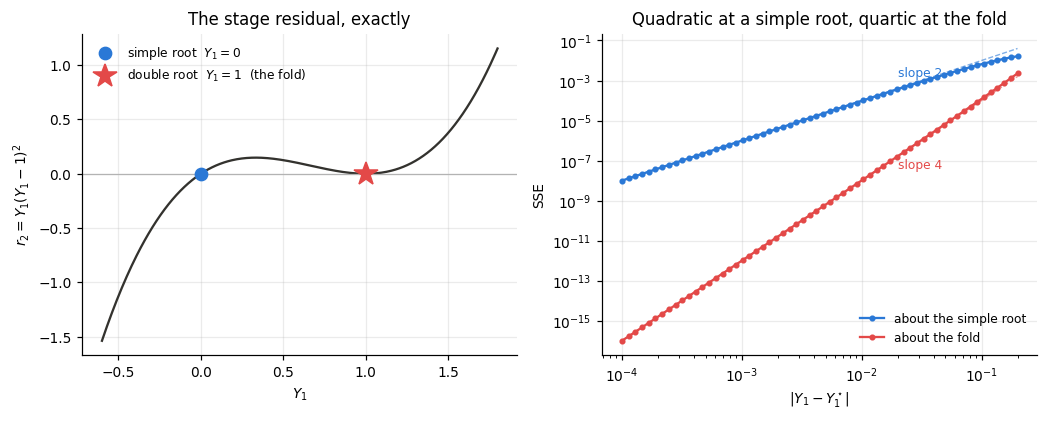

predicted descent error at the fold ~ SSE^(1/4) = 2.7e-04
observed in e1_recovery.csv                     = 3.2e-04


In [3]:
fq = pd.read_csv(RESULTS / "e1_fold_q1.csv")
display(fq)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))

y1 = np.linspace(-0.6, 1.8, 400)
axes[0].plot(y1, y1 * (y1 - 1)**2, color=C_EXACT)
axes[0].axhline(0, color="0.7", lw=0.8)
axes[0].plot([0], [0], "o", color=C_PRIN, ms=8, label="simple root  $Y_1=0$")
axes[0].plot([1], [0], "*", color=C_SPUR, ms=16, label="double root  $Y_1=1$  (the fold)")
axes[0].set_xlabel("$Y_1$"); axes[0].set_ylabel("$r_2 = Y_1(Y_1-1)^2$")
axes[0].set_title("The stage residual, exactly"); axes[0].legend(fontsize=8)

# Exponent of the loss about each root: slope 2 (simple) vs slope 4 (fold).
d = np.logspace(-4, -0.7, 60)
sse_simple = (d * (d - 1)**2)**2                 # about Y_1 = 0
sse_fold = ((1 + d) * d**2)**2                   # about Y_1 = 1
axes[1].loglog(d, sse_simple, "o-", ms=3, color=C_PRIN, label="about the simple root")
axes[1].loglog(d, sse_fold, "o-", ms=3, color=C_SPUR, label="about the fold")
for ref, lab, col in [(d**2 * 1.0, "slope 2", C_PRIN), (d**4 * 1.0, "slope 4", C_SPUR)]:
    axes[1].loglog(d, ref, "--", lw=0.9, color=col, alpha=0.6)
axes[1].text(2e-2, 1.5e-3, "slope 2", color=C_PRIN, fontsize=8)
axes[1].text(2e-2, 4e-8, "slope 4", color=C_SPUR, fontsize=8)
axes[1].set_xlabel(r"$|Y_1 - Y_1^\star|$"); axes[1].set_ylabel("SSE")
axes[1].set_title("Quadratic at a simple root, quartic at the fold")
axes[1].legend(fontsize=8, loc="lower right")
fig.tight_layout(); fig.savefig(FIGURES / "e1_exact_fold.png"); plt.show()

print(f"predicted descent error at the fold ~ SSE^(1/4) = {(5.5e-15)**0.25:.1e}")
print(f"observed in e1_recovery.csv                     = {fold.gap.iloc[0]:.1e}")

## 3. Several branches — and the loss cannot tell them apart

At $q=2$, $\Delta t = 4$ the implicit stage system has (at least) three roots. Random starts
reach all of them, and **every one is an exact global minimum of the SSE**.

Newton, started from an RK4 predictor, selects the branch continuously connected to
$\Delta t \to 0$ — the *principal* branch, and the only one Runge–Kutta order theory describes.
Note the root nearest the true $y(4)$ is **not** the principal one: proximity to the truth does
not identify the correct branch, and the loss, being zero at all of them, cannot either.

A classical solver picks the branch through its initial guess. **The RK-PINN loss contains no
such device.**

,root,y_next_1,y_next_2,sse,is_principal,dist_to_exact
0,0,-2.817685,3.925761,2.510136e-19,False,3.472006
1,1,-1.929101,-1.170854,8.989481e-20,True,1.805266
2,2,-1.684253,0.240602,2.904382e-19,False,0.388347


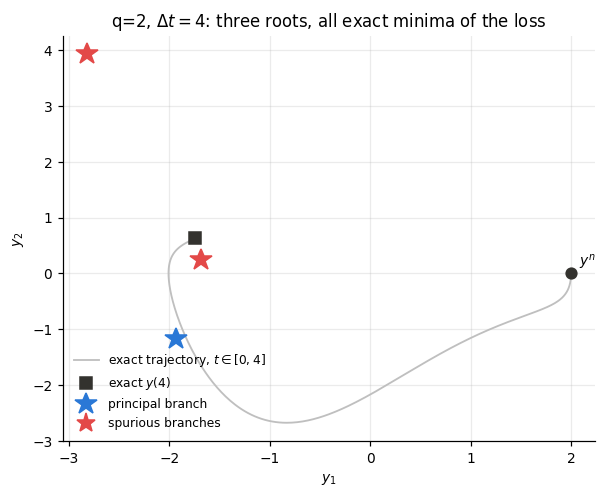

nearest the exact solution: root 2, principal = False


In [4]:
br = pd.read_csv(RESULTS / "e1_branches.csv")
display(br)

sol = reference(Y0, 4.0, MU)
ts = np.linspace(0, 4, 600)
traj = np.array([sol.sol(t) for t in ts])

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.plot(traj[:, 0], traj[:, 1], "-", color="0.75", lw=1.2, label="exact trajectory, $t\\in[0,4]$")
ax.plot(*Y0, "o", color=C_EXACT, ms=7); ax.annotate("$y^n$", Y0 + [0.08, 0.12])
ax.plot(*sol.sol(4.0), "s", color=C_EXACT, ms=8, label="exact $y(4)$")
for r in br.itertuples():
    col = C_PRIN if r.is_principal else C_SPUR
    ax.plot(r.y_next_1, r.y_next_2, "*", color=col, ms=15,
            label=("principal branch" if r.is_principal else None))
ax.plot([], [], "*", color=C_SPUR, ms=13, label="spurious branches")
ax.set_xlabel("$y_1$"); ax.set_ylabel("$y_2$")
ax.set_title("q=2, $\\Delta t=4$: three roots, all exact minima of the loss")
ax.legend(fontsize=8, loc="lower left"); fig.tight_layout()
fig.savefig(FIGURES / "e1_branches.png"); plt.show()

n = br.loc[br.dist_to_exact.idxmin()]
print(f"nearest the exact solution: root {int(n.root)}, principal = {bool(n.is_principal)}")

## 4. Where the branches fold, over the sampling region $D$

E1b: continuation in $\Delta t$ along the principal branch from each $y^n \in D$, warm-starting
Newton from the previous $\Delta t$. (A cold start would silently jump branches — the very
failure being measured.)

**Past a fold the network is asked to fit a function that does not exist.** The SSE will still
fall to zero, on a spurious branch, possibly a *different* branch at different $y^n$, giving a
discontinuous propagator that passes its own loss.

,q,earliest_fold,at_y1,at_y2,frac_safe_dt1,frac_safe_dt2
0,2,1.60,-2.083333,2.5,1.0,0.976331
1,4,2.76,-0.833333,3.0,1.0,1.000000
2,8,inf,NaN,NaN,1.0,1.000000


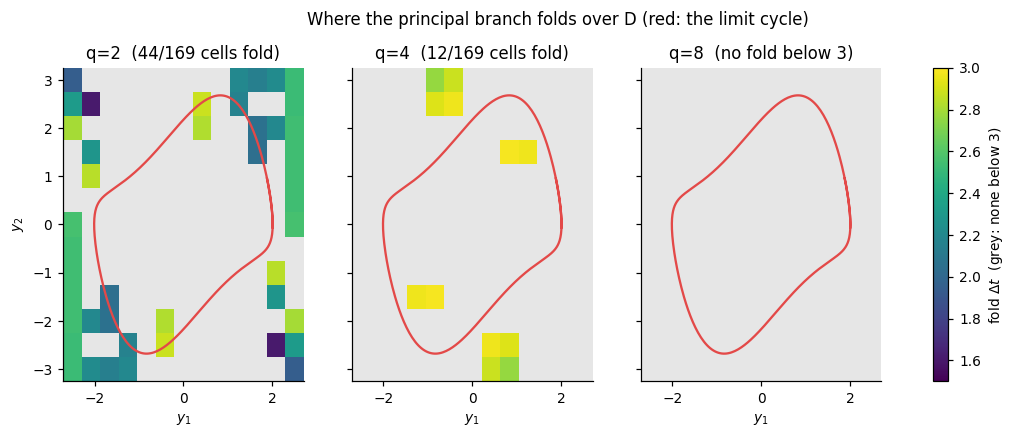

Folds cluster on the boundary of D, away from the limit cycle -- reassuring
for the E5 rollout, where trajectories settle onto the cycle.


In [5]:
surf = pd.read_csv(RESULTS / "e1_fold_surface.csv")
summ = pd.read_csv(RESULTS / "e1_fold_summary.csv")
display(summ)

import copy
qs = sorted(surf.q.unique())
cmap = copy.copy(plt.get_cmap("viridis"))
cmap.set_bad("0.90")                       # grey where no fold was met below dt_max

fig, axes = plt.subplots(1, len(qs), figsize=(4.0*len(qs), 3.7), sharey=True)
sol = reference(np.array([2.0, 0.0]), 40.0, MU)          # settle onto the limit cycle
lc = np.array([sol.sol(t) for t in np.linspace(33, 40, 500)])
for ax, q in zip(np.atleast_1d(axes), qs):
    g = surf[surf.q == q]
    P = np.ma.masked_invalid(g.pivot(index="y2", columns="y1", values="fold_dt").values)
    im = ax.pcolormesh(sorted(g.y1.unique()), sorted(g.y2.unique()), P,
                       cmap=cmap, vmin=1.5, vmax=3.0, shading="nearest")
    ax.plot(lc[:, 0], lc[:, 1], "-", color=C_SPUR, lw=1.5)
    n_fold = int(np.isfinite(g.fold_dt).sum())
    ax.set_title(f"q={q}" + ("  (no fold below 3)" if n_fold == 0
                             else f"  ({n_fold}/{len(g)} cells fold)"))
    ax.set_xlabel("$y_1$"); ax.grid(False)
np.atleast_1d(axes)[0].set_ylabel("$y_2$")
fig.colorbar(im, ax=list(np.atleast_1d(axes)), label=r"fold $\Delta t$  (grey: none below 3)")
fig.suptitle("Where the principal branch folds over D (red: the limit cycle)", y=1.02)
fig.savefig(FIGURES / "e1_fold_surface.png", bbox_inches="tight"); plt.show()

print("Folds cluster on the boundary of D, away from the limit cycle -- reassuring")
print("for the E5 rollout, where trajectories settle onto the cycle.")

**Larger $q$ pushes the fold out.** That is a second reason the paper's large-$q$ regime
works, independent of the order being $2q$, and it is consistent with Raissi taking $q=100$ at
$\Delta t = 0.8$ on Allen–Cahn.

Note the classical sufficient condition for a unique stage solution,
$\Delta t\, L \max_i \sum_j |a_{ij}| < 1$, predicts the **opposite** trend: with $L = 16.8$ on
$D$ it guarantees nothing past $\Delta t \approx 0.12$, and it *tightens* with $q$. Merely
sufficient, and useless here.

> **Caveat.** Measured on a $13\times13$ grid, continuation step $0.02$, singular-value
> tolerance $10^{-2}$, up to $\Delta t = 3$, at $\mu = 1$. A grid can only give an **upper**
> bound on the earliest fold in $D$, and nothing is learned above $\Delta t = 3$.
> This is measured, not proved.

## Consequences for E3

1. **A floor below the capacity floor.** Parameter error $\sim \sqrt{\mathrm{SSE}}$, whatever
   the network. Report both floors separately or the capacity result will be misread.
2. **The $\Delta t$ sweep must be chosen per $q$.** A single range for all $q$ is unsound:
   $q=1$ folds at $\Delta t = 2$ and $q=2$ at $\Delta t \approx 1.6$, while $q=8$ has no fold below 3.
3. **Watch for branch capture.** Diagnose by comparing $\Phi_\theta$ against `rk_core.irk_step`
   *warm-started along the principal branch*, never against a cold-start Newton.